In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("data.csv", encoding="latin1")

/tmp/ipykernel_4227/544688464.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv", encoding="latin1")


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [7]:
df.isnull().sum()

,0
stn_code,144077
sampling_date,3
state,0
location,3
agency,149481
type,5393
so2,34646
no2,16233
rspm,40222
spm,237387


In [8]:
null_percentages = (df.isnull().sum() / len(df)) * 100
print(null_percentages)

stn_code                       33.064749
sampling_date                   0.000688
state                           0.000000
location                        0.000688
agency                         34.304933
type                            1.237659
so2                             7.951035
no2                             3.725370
rspm                            9.230692
spm                            54.478797
location_monitoring_station     6.309009
pm2_5                          97.862497
date                            0.001606
dtype: float64


In [9]:
df.drop(columns=['pm2_5'], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  date                         435735 non-null  object 
dtypes: float64(4), object(8)
memory usage: 39.9+ MB


In [11]:
null_percentages = (df.isnull().sum() / len(df)) * 100
print(null_percentages)

stn_code                       33.064749
sampling_date                   0.000688
state                           0.000000
location                        0.000688
agency                         34.304933
type                            1.237659
so2                             7.951035
no2                             3.725370
rspm                            9.230692
spm                            54.478797
location_monitoring_station     6.309009
date                            0.001606
dtype: float64


### Dropping columns with high null percentages and handling remaining null values

In [12]:
df.drop(columns=['spm', 'stn_code', 'agency'], inplace=True)
print("Columns 'spm', 'stn_code', and 'agency' dropped.")

Columns 'spm', 'stn_code', and 'agency' dropped.


In [13]:
# Drop rows where 'sampling_date', 'location', or 'date' are null (very few cases)
df.dropna(subset=['sampling_date', 'location', 'date'], inplace=True)
print("Rows with nulls in 'sampling_date', 'location', or 'date' dropped.")

Rows with nulls in 'sampling_date', 'location', or 'date' dropped.


In [14]:
# Impute numerical columns with mean
for col in ['so2', 'no2', 'rspm']:
    df[col].fillna(df[col].mean(), inplace=True)
print("Nulls in 'so2', 'no2', 'rspm' imputed with mean.")

Nulls in 'so2', 'no2', 'rspm' imputed with mean.


/tmp/ipykernel_4227/3545414895.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [15]:
# Impute categorical columns with mode
for col in ['type', 'location_monitoring_station']:
    df[col].fillna(df[col].mode()[0], inplace=True)
print("Nulls in 'type' and 'location_monitoring_station' imputed with mode.")

Nulls in 'type' and 'location_monitoring_station' imputed with mode.


/tmp/ipykernel_4227/1709324122.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [16]:
print("\nShape before outlier removal:", df.shape)

# Outlier detection and removal using IQR method for numerical columns
for col in ['so2', 'no2', 'rspm']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print(f"Outliers removed for column: {col}")

print("Shape after outlier removal:", df.shape)


Shape before outlier removal: (435735, 9)
Outliers removed for column: so2
Outliers removed for column: no2
Outliers removed for column: rspm
Shape after outlier removal: (372035, 9)


In [17]:
# Verify no more nulls exist
print("\nRemaining null values after cleaning:")
print(df.isnull().sum())


Remaining null values after cleaning:
sampling_date                  0
state                          0
location                       0
type                           0
so2                            0
no2                            0
rspm                           0
location_monitoring_station    0
date                           0
dtype: int64


### Data Type Conversion

In [18]:
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])
print("\n'date' column converted to datetime.")
df.info()


'date' column converted to datetime.
<class 'pandas.core.frame.DataFrame'>
Index: 372035 entries, 0 to 435738
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   sampling_date                372035 non-null  object        
 1   state                        372035 non-null  object        
 2   location                     372035 non-null  object        
 3   type                         372035 non-null  object        
 4   so2                          372035 non-null  float64       
 5   no2                          372035 non-null  float64       
 6   rspm                         372035 non-null  float64       
 7   location_monitoring_station  372035 non-null  object        
 8   date                         372035 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 28.4+ MB


### Data Analysis and Visualization

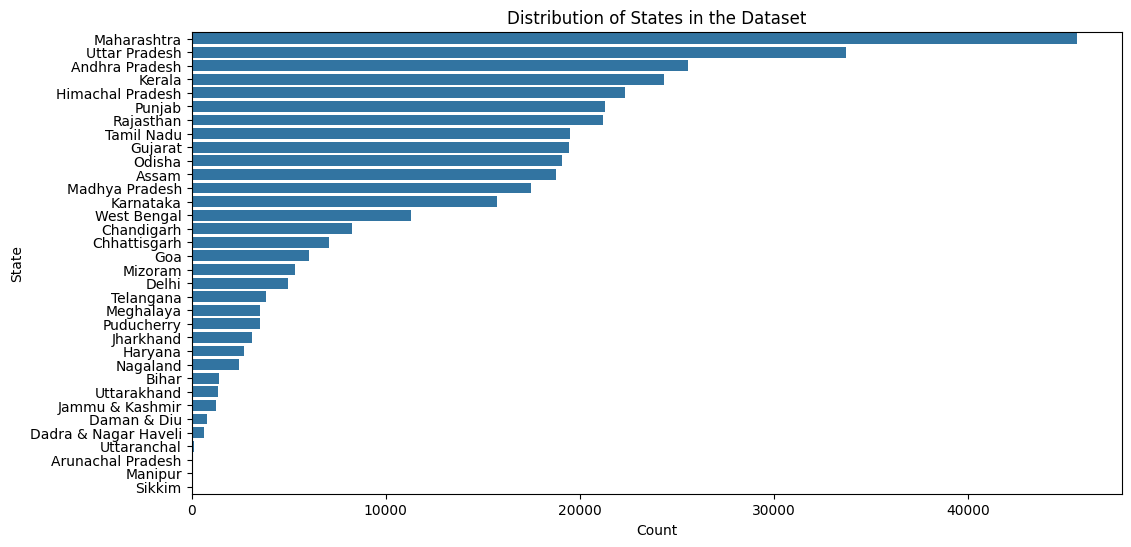

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of states
plt.figure(figsize=(12, 6))
sns.countplot(y='state', data=df, order = df['state'].value_counts().index)
plt.title('Distribution of States in the Dataset')
plt.xlabel('Count')
plt.ylabel('State')
plt.show()

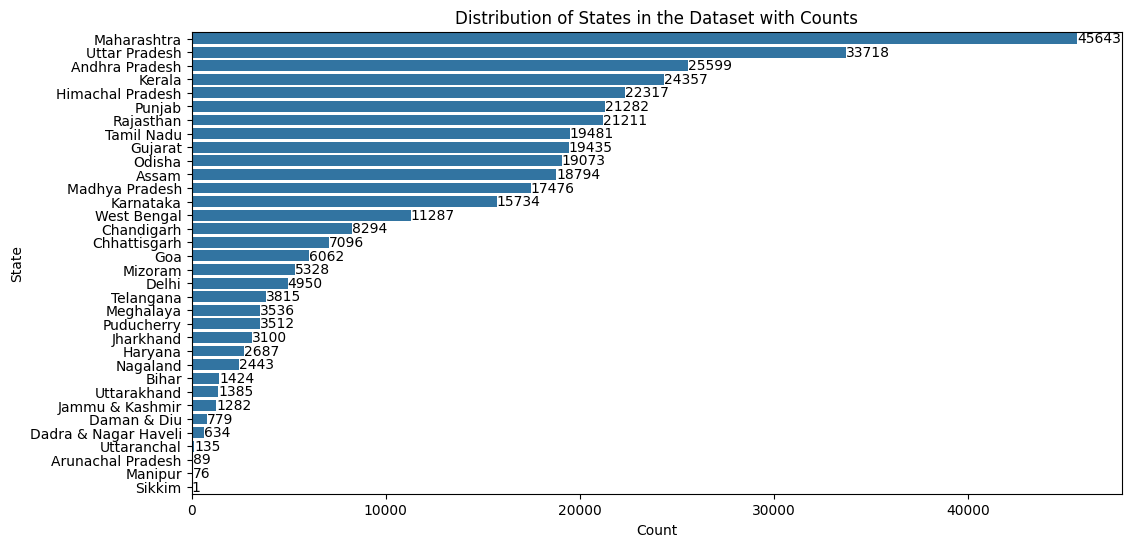

In [21]:
# Re-generating the 'Distribution of States' chart with count labels
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
ax = sns.countplot(y='state', data=df, order = df['state'].value_counts().index)
plt.title('Distribution of States in the Dataset with Counts')
plt.xlabel('Count')
plt.ylabel('State')

# Add count labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

<Figure size 1500x800 with 0 Axes>

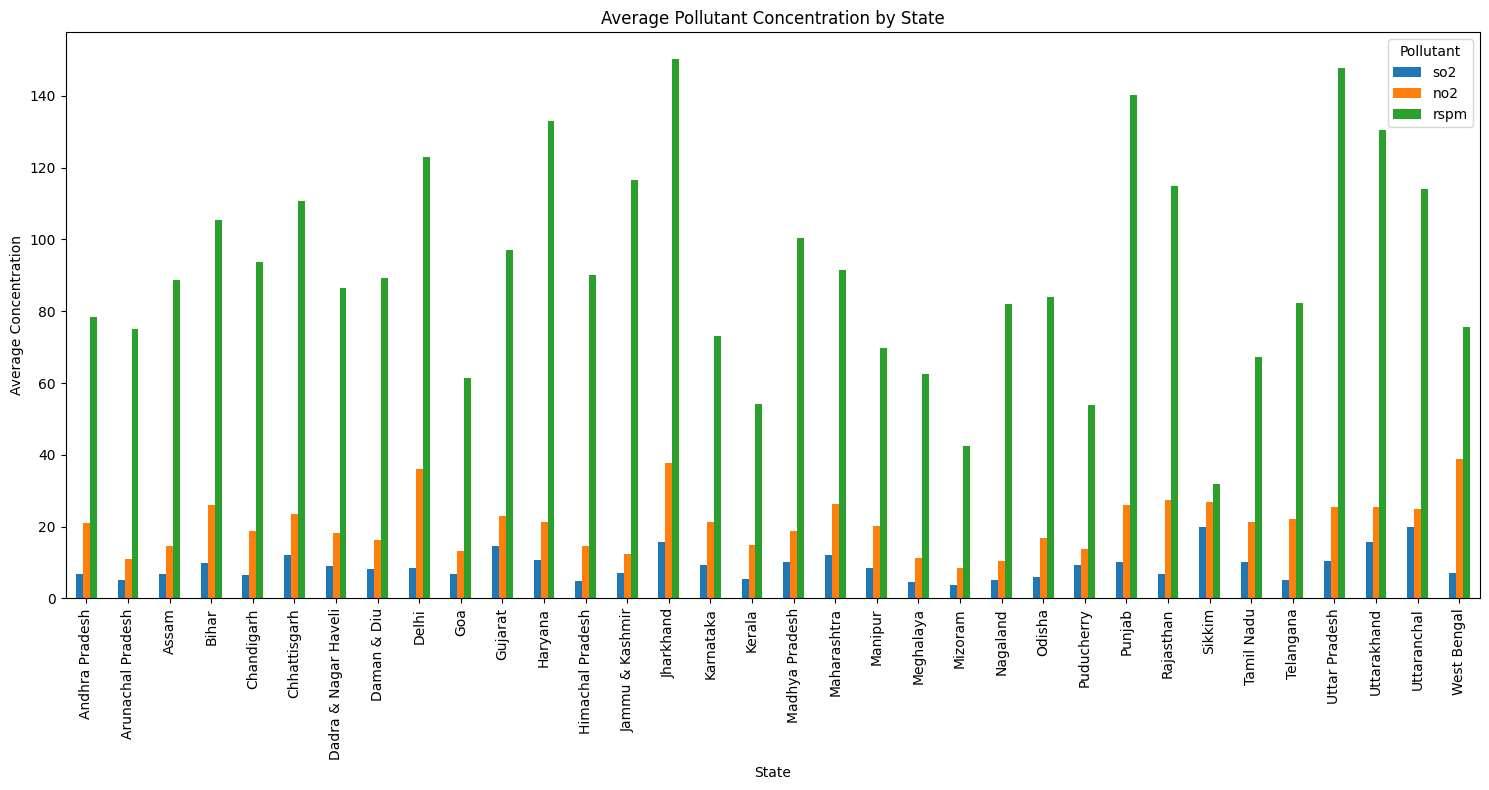

In [20]:
# Average concentration of pollutants by state
state_avg_pollutants = df.groupby('state')[['so2', 'no2', 'rspm']].mean().reset_index()

plt.figure(figsize=(15, 8))
state_avg_pollutants.set_index('state').plot(kind='bar', figsize=(15, 8))
plt.title('Average Pollutant Concentration by State')
plt.xlabel('State')
plt.ylabel('Average Concentration')
plt.xticks(rotation=90)
plt.legend(title='Pollutant')
plt.tight_layout()
plt.show()

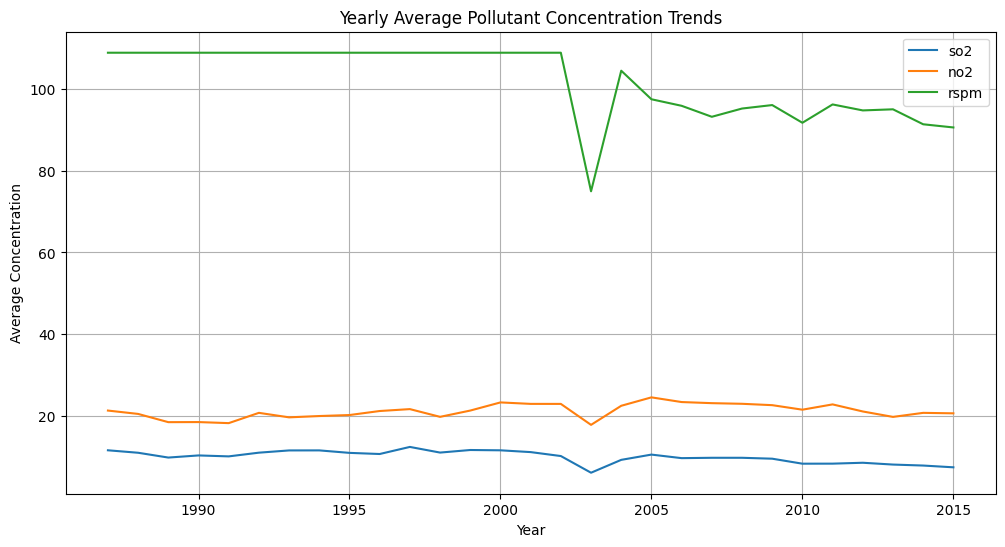

In [23]:
# Time-series analysis: Trends of pollutants over time (yearly average)
df['year'] = df['date'].dt.year
yearly_avg_pollutants = df.groupby('year')[['so2', 'no2', 'rspm']].mean().reset_index()

plt.figure(figsize=(12, 6))
for col in ['so2', 'no2', 'rspm']:
    sns.lineplot(x='year', y=col, data=yearly_avg_pollutants, label=col)
plt.title('Yearly Average Pollutant Concentration Trends')
plt.xlabel('Year')
plt.ylabel('Average Concentration')
plt.legend()
plt.grid(True)
plt.show()

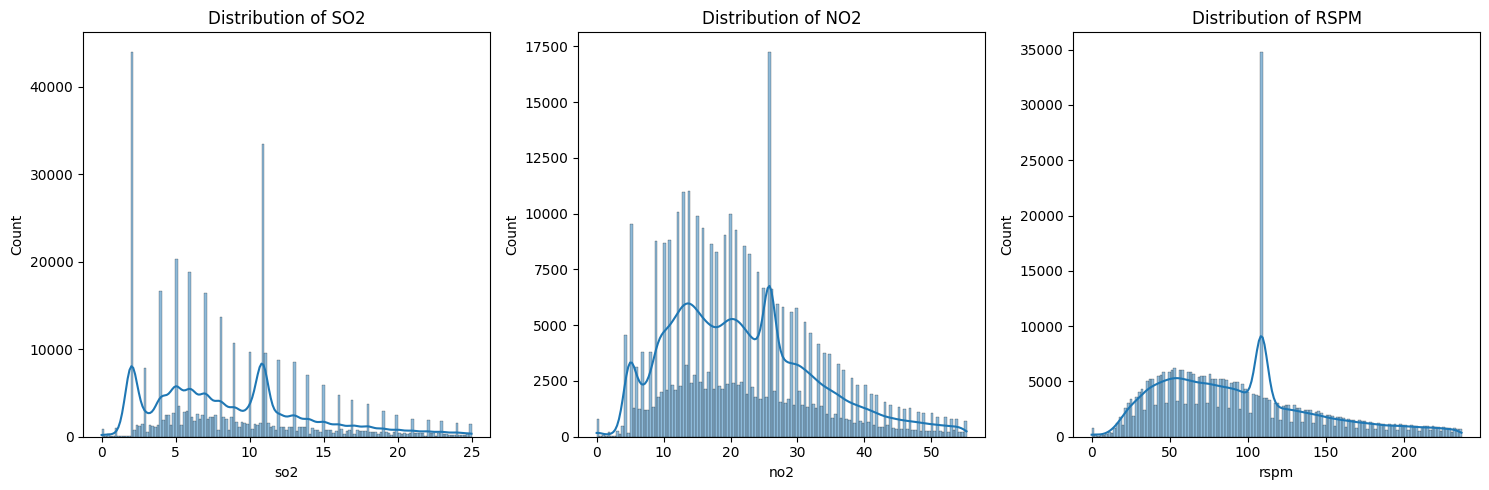

In [24]:
# Distribution of individual pollutants
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['so2'], kde=True)
plt.title('Distribution of SO2')

plt.subplot(1, 3, 2)
sns.histplot(df['no2'], kde=True)
plt.title('Distribution of NO2')

plt.subplot(1, 3, 3)
sns.histplot(df['rspm'], kde=True)
plt.title('Distribution of RSPM')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4227/3993009281.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rspm', y='state', data=state_rspm.head(15), palette='viridis')


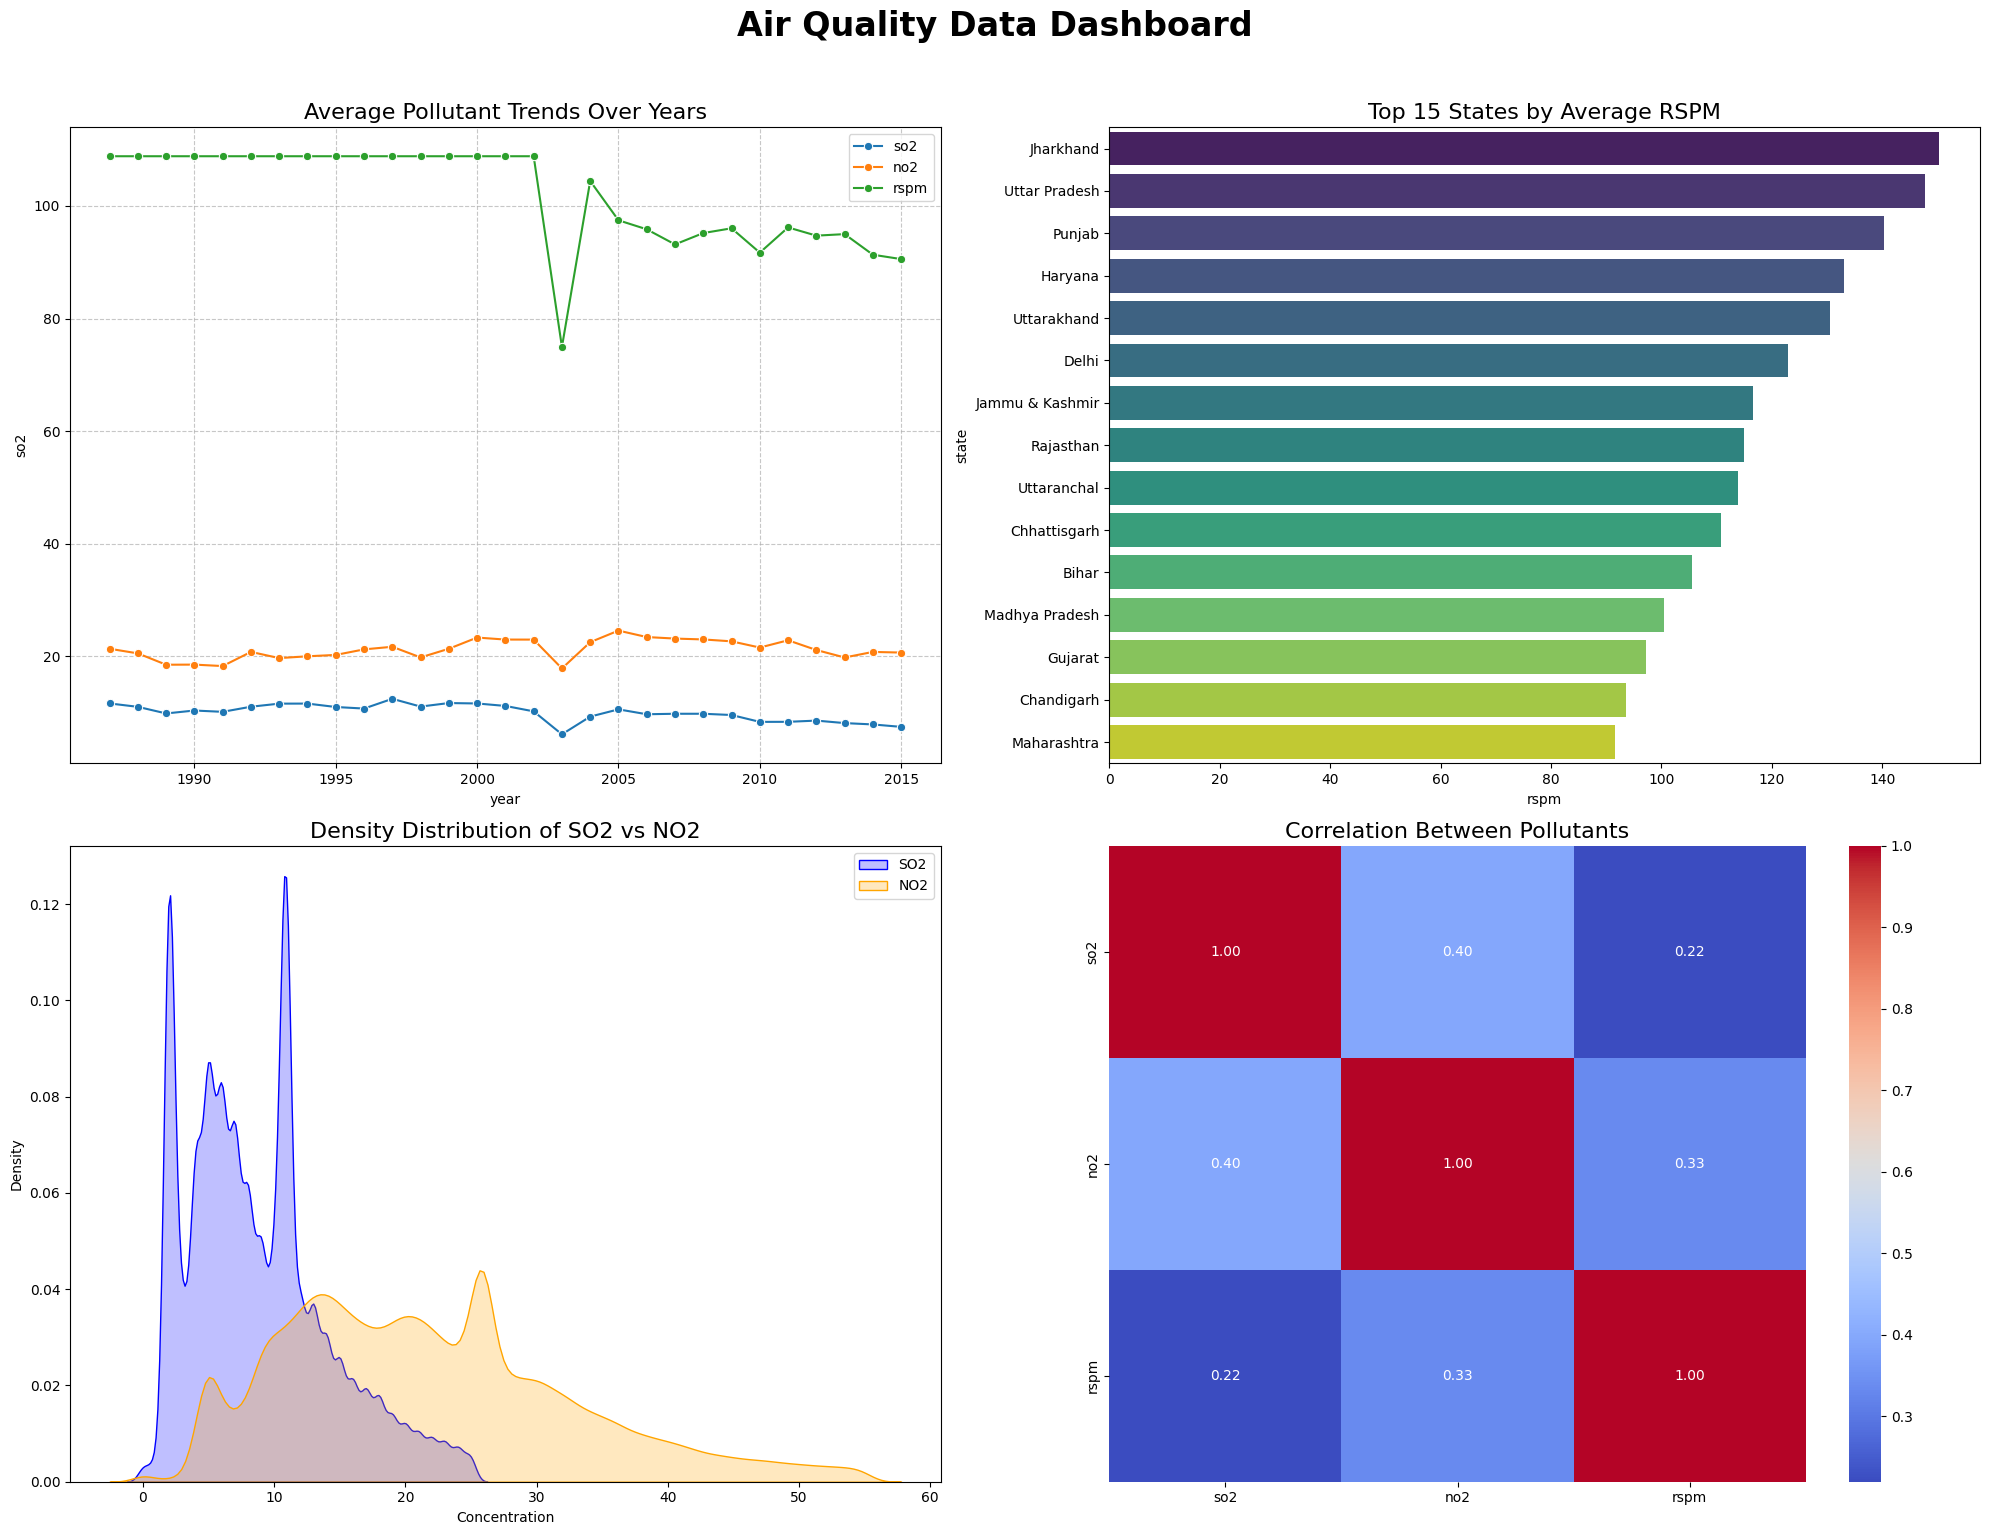

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a multi-panel dashboard
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Air Quality Data Dashboard', fontsize=24, fontweight='bold', y=1.02)

# 1. Yearly Trends
plt.subplot(2, 2, 1)
for col in ['so2', 'no2', 'rspm']:
    sns.lineplot(x='year', y=col, data=yearly_avg_pollutants, label=col, marker='o')
plt.title('Average Pollutant Trends Over Years', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. State-wise RSPM Concentration
plt.subplot(2, 2, 2)
state_rspm = state_avg_pollutants.sort_values('rspm', ascending=False)
sns.barplot(x='rspm', y='state', data=state_rspm.head(15), palette='viridis')
plt.title('Top 15 States by Average RSPM', fontsize=16)

# 3. Pollutant Distributions (SO2 and NO2)
plt.subplot(2, 2, 3)
sns.kdeplot(df['so2'], fill=True, label='SO2', color='blue')
sns.kdeplot(df['no2'], fill=True, label='NO2', color='orange')
plt.title('Density Distribution of SO2 vs NO2', fontsize=16)
plt.xlabel('Concentration')
plt.legend()

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
correlation_matrix = df[['so2', 'no2', 'rspm']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Pollutants', fontsize=16)

plt.tight_layout()
plt.show()

# The Air Quality Story: Analysis Summary

### 1. Data Refining
- We started with a massive dataset of over **435,000 records**. The initial exploration revealed significant missing data, especially in the `pm2_5` (97% null) and `spm` (54% null) columns, which were removed to ensure analysis integrity. We handled remaining gaps by imputing numerical values with the **mean** and categorical labels with the **mode**.

### 2. Sharpening the Focus
- To prevent extreme values from skewing our insights, we applied the **IQR (Interquartile Range) method**. This process filtered out outliers in SO2, NO2, and RSPM levels, leaving us with a robust dataset of **372,035 high-quality samples**.

### 3. Key Insights from the Dashboard
*   **Historical Trends:** Our time-series analysis showed that while **SO2 levels have generally declined** since the late 1980s, **NO2 and RSPM levels remain persistent challenges**, showing more volatility over the decades.
*   **Regional Hotspots:** The state-wise analysis identified **Jharkhand and Uttar Pradesh** among the top states with the highest average RSPM (Respirable Suspended Particulate Matter) concentrations.
*   **Pollutant Relationships:** The correlation heatmap revealed a moderate positive relationship between **SO2 and NO2**, suggesting they often originate from similar industrial or combustion sources.
*   **Atmospheric Density:** Most monitoring stations record relatively low concentrations of SO2, while NO2 shows a broader distribution, indicating more widespread presence across the sampled locations.